# [LAB-09] 6. [PBT] 회귀모형 평가와 진단

## #01. 준비작업

### 1. 라이브러리 참조

In [5]:
from jussam import load_data
from helper import *

import numpy as np
from pandas import DataFrame, concat
from IPython.display import Markdown

# 성능 평가 지표 (직접 계산하지 않고 sklearn 의 함수를 사용한다)
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

### 2. 체크포인트 데이터 로드

- 전처리 단계가 하나씩 누적된 5개의 데이터셋을 불러온다.

In [6]:
df0 = load_data("boston_checkpoint_0")
df1 = load_data("boston_checkpoint_1")
df2 = load_data("boston_checkpoint_2")
df3 = load_data("boston_checkpoint_3")
df4 = load_data("boston_checkpoint_4")

📚 보스턴 주택 가격 데이터셋의 전처리 체크포인트 0 - 기준선 역할을 위해 라벨링과 더미변수 처리만 적용됨
📚 보스턴 주택 가격 데이터셋의 전처리 체크포인트 1 - 라벨링 + 더미변수 + 로그변환
📚 보스턴 주택 가격 데이터셋의 전처리 체크포인트 2 - 라벨링 + 더미변수 + 로그변환 + 이상치 대체
📚 보스턴 주택 가격 데이터셋의 전처리 체크포인트 3 - 라벨링 + 더미변수 + 로그변환 + 이상치 대체 + 다중공선성제거
📚 보스턴 주택 가격 데이터셋의 전처리 체크포인트 4 - 라벨링 + 더미변수 + 로그변환 + 이상치 대체 + 다중공선성제거 + 스케일링


### 3. 분석 대상 정리

In [7]:
# 종속변수
target = "MEDV"

# 비교 대상 체크포인트 (아래로 갈수록 전처리가 하나씩 누적된다)
checkpoints = { "0_기준선": df0, "1_로그변환": df1, "2_이상치대체": df2, "3_공선성제거": df3, "4_스케일링": df4}

# 종속변수(MEDV)에 log1p 가 적용되었는지 여부 (체크포인트 1부터 적용됨)
logqp_y = { "0_기준선": False, "1_로그변환": True, "2_이상치대체": True, "3_공선성제거": True, "4_스케일링": True}

# 로그변환(log)이 적용된 독립변수 → 최종 모델의 회귀계수 해석에 사용한다
log_x = {"CRIM", "DIS", "RAD", "LSTAT"}

# 로그1p변환(log1p)이 적용된 독립변수 → 최종 모델의 회귀계수 해석에 사용한다
log1p_x = ["ZN"]

# 반전 로그 변환이 적용된 독립변수
reflect_x = ["B"]

### 4. 종속변수 척도 확인

- 체크포인트 1 이후부터 종속변수의 척도가 다름을 확인

In [10]:
medv_scale = DataFrame()

for name in checkpoints:
    data = checkpoints[name]
    medv_scale[name] = data[target].describe()

medv_scale.round(3)

,0_기준선,1_로그변환,2_이상치대체,3_공선성제거,4_스케일링
count,506.000,506.000,506.000,506.000,506.000
mean,22.533,3.035,3.035,3.035,3.035
std,9.197,0.409,0.409,0.409,0.409
min,5.000,1.609,1.609,1.609,1.609
25%,17.025,2.835,2.835,2.835,2.835
50%,21.200,3.054,3.054,3.054,3.054
75%,25.000,3.219,3.219,3.219,3.219
max,50.000,3.912,3.912,3.912,3.912


## #02. 체크포인트별 모델 적합 및 성능 비교

### 1. 체크포인트마다 모델을 적합(후진소거 포함)

- 예측값을 **원본 척도(천 달러)로 되돌려** 성능을 계산한다.

In [12]:
fits = {}
result = []

for c in checkpoints:
    data = checkpoints[c]       # 체크포인트 데이터프레임
    log = log1p_y[c]            # 종속변수에 log1p가 적용되었는지 여부

    # 1) 모델 적합 (후진제거 포함)
    fit = my_ols.auto_ols(data, target, log1p_y=log, log_x=log_x, log1p_x=log1p_x, reflect_x=reflect_x, backward=True, report=False, test=False)

    fits[c] = fit

    # 2) 실제값과 예측값을 원본 척도(천 달러)로 되돌린다
    if log:
        y_true = np.expm1(data[target])         # 종속변수 역변환
        y_pred = np.expm1(fit.fittedvalues)     # 예측값 역변환
    else:
        y_true = data[target]                   # 체크포인트 0 은 이미 원본 척도
        y_pred = fit.fittedvalues

    # 3) 지표를 한 행으로 정리해 저장
    result.append({
        "모델" : c,
        "변수수" : int(fit.df_model),           # 상수항을 제외한 독립변수 개수
        "R2(모델척도)" : fit.rsquared,          # 체크포인트간 비교 불가 (참고용)
        "Adj.R2" : fit.rsquared_adj,            # 같은 종속변수끼리만 비교
        "AIC" : fit.aic,                        # 같은 종속변수끼리만 비교 (작을수록 좋음)
        "BIC" : fit.bic,                        # 같은 종속변수끼리만 비교 (작을수록 좋음)
        # 아래 세 지표는 원본 척도에서 계산하므로 체크포인트간 비교가 가능하다
        "R2(원본척도)" : r2_score(y_true, y_pred),
        "RMSE" : root_mean_squared_error(y_true, y_pred),   # 최종 선택 기준
        "MAE" : mean_absolute_error(y_true, y_pred),
    })
    


유의하지 않은 독립변수 제거 → AGE (p = 0.9678)
유의하지 않은 독립변수 제거 → INDUS (p = 0.6898)

유의하지 않은 독립변수 제거 → B (p = 0.9465)
유의하지 않은 독립변수 제거 → INDUS (p = 0.2089)
유의하지 않은 독립변수 제거 → AGE (p = 0.1922)

유의하지 않은 독립변수 제거 → B (p = 0.9141)
유의하지 않은 독립변수 제거 → AGE (p = 0.2096)
유의하지 않은 독립변수 제거 → INDUS (p = 0.1943)

유의하지 않은 독립변수 제거 → B (p = 0.9141)
유의하지 않은 독립변수 제거 → AGE (p = 0.2096)
유의하지 않은 독립변수 제거 → INDUS (p = 0.1943)

유의하지 않은 독립변수 제거 → B (p = 0.9141)
유의하지 않은 독립변수 제거 → AGE (p = 0.2096)
유의하지 않은 독립변수 제거 → INDUS (p = 0.1943)


### 2. 최종 모델 채택 → `1_로그변환`

성능표를 슬라이드의 채택 기준(**1순위 원본 척도 RMSE, 2순위 간명성**)으로 읽으면 `1_로그변환` 이 선택된다.

| 항목 | 값 |
|:---|:---|
| 전처리 | 라벨링 + 더미변수 + **로그변환** |
| 독립변수 | **10개** (전체 13개 중 `B`·`INDUS`·`AGE` 제거) |
| RMSE (원본 척도) | **4.336** (천 달러) |
| MAE / R² (원본 척도) | 3.075 / 0.777 |

In [13]:
final_fit = fits["1_로그변환"]
final_data = checkpoints["1_로그변환"]

## #03. 최종 모델 분석 결과 보고

### 1. 모형 적합도

In [7]:
display(Markdown(
    my_ols.report_fitness(final_fit, log1p_y=True, log_x=log_x, 
                          log1p_x=log1p_x, reflect_x=reflect_x)
))

**Note.n =506.F(10, 495) = 158.21, p < 0.001, R² = (np.float64(0.7616862665974207), 3), Adj.R² = (np.float64(0.756871847740803), 3), Durbin-Watson = 0.945**

log1p(MEDV)를 종속변수로, log(CRIM), log1p(ZN), CHAS, NOX, RM, log(DIS), log(RAD), TAX, PTRATIO, log(LSTAT)(을)를 독립변수로한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다.

> F(10, 495) = 158.21, p < 0.001, R² = (np.float64(0.7616862665974207), 3).

즉, log(CRIM), log1p(ZN), CHAS, NOX, RM, log(DIS), log(RAD), TAX, PTRATIO, log(LSTAT)는 log1p(MEDV)의 약 76.17%를 설명하는 것으로 나타났다.

### 2. 회귀계수 보고표

In [15]:
my_ols.report_variables(final_fit, final_data, hc3=final_fit.use_hc3_)

,종속변수,독립변수,B,표준오차,표준오차(HC3),β,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,MEDV,LSTAT,-0.397,0.025,0.036,-0.584,-15.980,-10.983,0.000,0.000,0.360,2.774
1,MEDV,DIS,-0.169,0.034,0.039,-0.223,-5.035,-4.369,0.000,0.000,0.244,4.092
2,MEDV,TAX,-0.001,0.000,0.000,-0.222,-4.510,-4.625,0.000,0.000,0.200,5.011
3,MEDV,RAD,0.102,0.023,0.020,0.218,4.368,5.157,0.000,0.000,0.193,5.189
4,MEDV,CRIM,-0.036,0.011,0.011,-0.191,-3.245,-3.159,0.001,0.002,0.139,7.194
5,MEDV,PTRATIO,-0.032,0.006,0.004,-0.168,-5.664,-7.101,0.000,0.000,0.546,1.831
6,MEDV,NOX,-0.564,0.167,0.187,-0.160,-3.375,-3.014,0.001,0.003,0.215,4.657
7,MEDV,RM,0.074,0.018,0.026,0.127,4.201,2.792,0.000,0.005,0.526,1.900
8,MEDV,CHAS,0.114,0.036,0.039,0.071,3.127,2.893,0.002,0.004,0.946,1.058
9,MEDV,ZN,-0.015,0.008,0.007,-0.059,-1.806,-2.245,0.071,0.025,0.452,2.214


### 3. 영향력 순위 시각화 (표준화 계수 β)

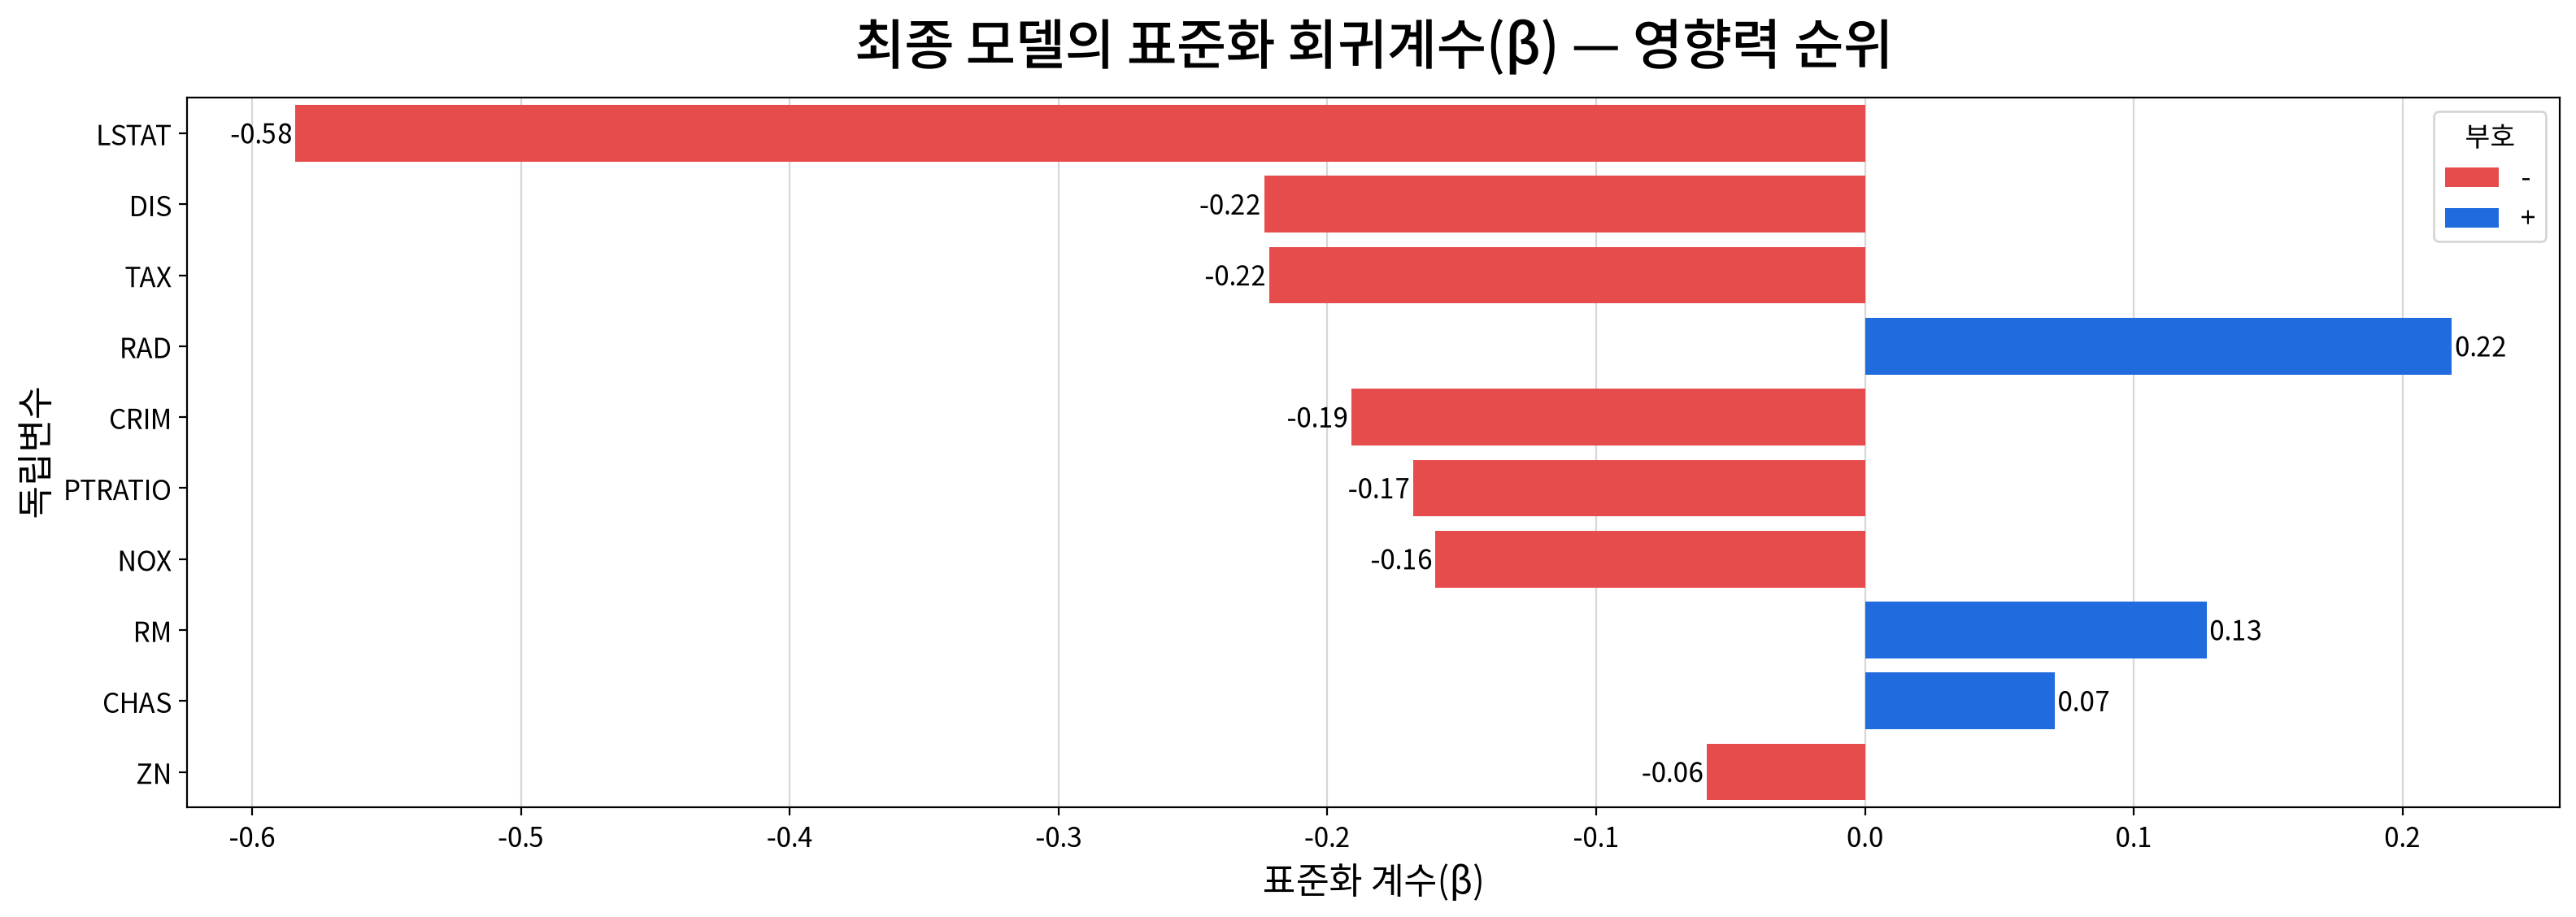

In [16]:
my_ols.plot_beta(final_fit, final_data, height=580, width=1600,
                 title="최종 모델의 표준화 회귀계수(β) — 영향력 순위")

### 4. 회귀계수 해석 문장

In [17]:
display(Markdown(
    my_ols.report_variables_text(final_fit,
                                 log1p_y=True, 
                                 log_x=log_x, 
                                 log1p_x=log1p_x, 
                                 reflect_x=reflect_x,
                                 hc3=final_fit.use_hc3_)
))

- **CRIM**의 회귀계수는 **B = -0.04**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(495) = -3.16**, **p =  . 002**) 즉, CRIM가 **1% 증가**할 때 **(1+MEDV)**는 평균적으로 약 **0.04% 감소**하는 것으로 해석된다.
- **ZN**의 회귀계수는 **B = -0.01**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(495) = -2.24**, **p =  . 025**) 즉, **(1+ZN)가 1% 증가**할 때 **(1+MEDV)**는 평균적으로 약 **0.01% 감소**하는 것으로 해석된다.
- **CHAS**의 회귀계수는 **B = 0.11**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(495) = 2.89**, **p =  . 004**) 즉, CHAS가 **1 증가**할 때 **(1+MEDV)**는 평균적으로 약 **12.02% 증가**하는 것으로 해석된다.
- **NOX**의 회귀계수는 **B = -0.56**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(495) = -3.01**, **p =  . 003**) 즉, NOX가 **1 증가**할 때 **(1+MEDV)**는 평균적으로 약 **43.09% 감소**하는 것으로 해석된다.
- **RM**의 회귀계수는 **B = 0.07**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(495) = 2.79**, **p =  . 005**) 즉, RM가 **1 증가**할 때 **(1+MEDV)**는 평균적으로 약 **7.67% 증가**하는 것으로 해석된다.
- **DIS**의 회귀계수는 **B = -0.17**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(495) = -4.37**, **p < .001**) 즉, DIS가 **1% 증가**할 때 **(1+MEDV)**는 평균적으로 약 **0.17% 감소**하는 것으로 해석된다.
- **RAD**의 회귀계수는 **B = 0.1**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(495) = 5.16**, **p < .001**) 즉, RAD가 **1% 증가**할 때 **(1+MEDV)**는 평균적으로 약 **0.10% 증가**하는 것으로 해석된다.
- **TAX**의 회귀계수는 **B = -0.0**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(495) = -4.62**, **p < .001**) 즉, TAX가 **1 증가**할 때 **(1+MEDV)**는 평균적으로 약 **0.05% 감소**하는 것으로 해석된다.
- **PTRATIO**의 회귀계수는 **B = -0.03**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(495) = -7.1**, **p < .001**) 즉, PTRATIO가 **1 증가**할 때 **(1+MEDV)**는 평균적으로 약 **3.13% 감소**하는 것으로 해석된다.
- **LSTAT**의 회귀계수는 **B = -0.4**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(495) = -10.98**, **p < .001**) 즉, LSTAT가 **1% 증가**할 때 **(1+MEDV)**는 평균적으로 약 **0.40% 감소**하는 것으로 해석된다.

> ※ **log1p**(=ln(1+·))의 % 해석은 변수 자체가 아니라 **(1+변수)** 기준이며, 값이 클 때만 위 근사가 성립한다.      
(0·작은 값 구간에서는 원본처럼 동작해 부정확)      
이 구간에서는 부호·유의성 중심으로 해석하거나 예측값을 expm1로 원 척도에서 비교한다.

> ※ **반사 후 log1p**(=ln(1+max-·))는 값의 대소가 뒤집힌 변환이다. 위 %·증감은 **(1+max-변수)** 기준이고,     
원 변수 기준 방향은 각 문장 끝 괄호에 적었다.      
변수가 **최댓값에 가까운 구간**에서는 위 근사가 부정확하므로 부호·유의성 중심으로 읽고,      
원 척도 값은 **max-(exp(변환값)-1)** 로 되돌려 비교한다.

> ※ 위 **t**와 **유의확률**은 등분산 가정이 충족되지 않은 경우를 대비해 **HC3 로버스트 표준오차**로 계산한 값이다.     
회귀계수(B)와 효과 크기 해석은 일반 OLS와 동일하며,     
표준오차만 이분산에 강건하게 보정되어 유의성 판정이 달라질 수 있다.

## #04. 최종 모델의 회귀분석 가정 검정

### 1. 선형성 검정

,statistic,p-value,linearity,result
Ramsey RESET,15.127,0.000,False,대립가설 채택 -> 선형성 위배(곡선 관계 존재)


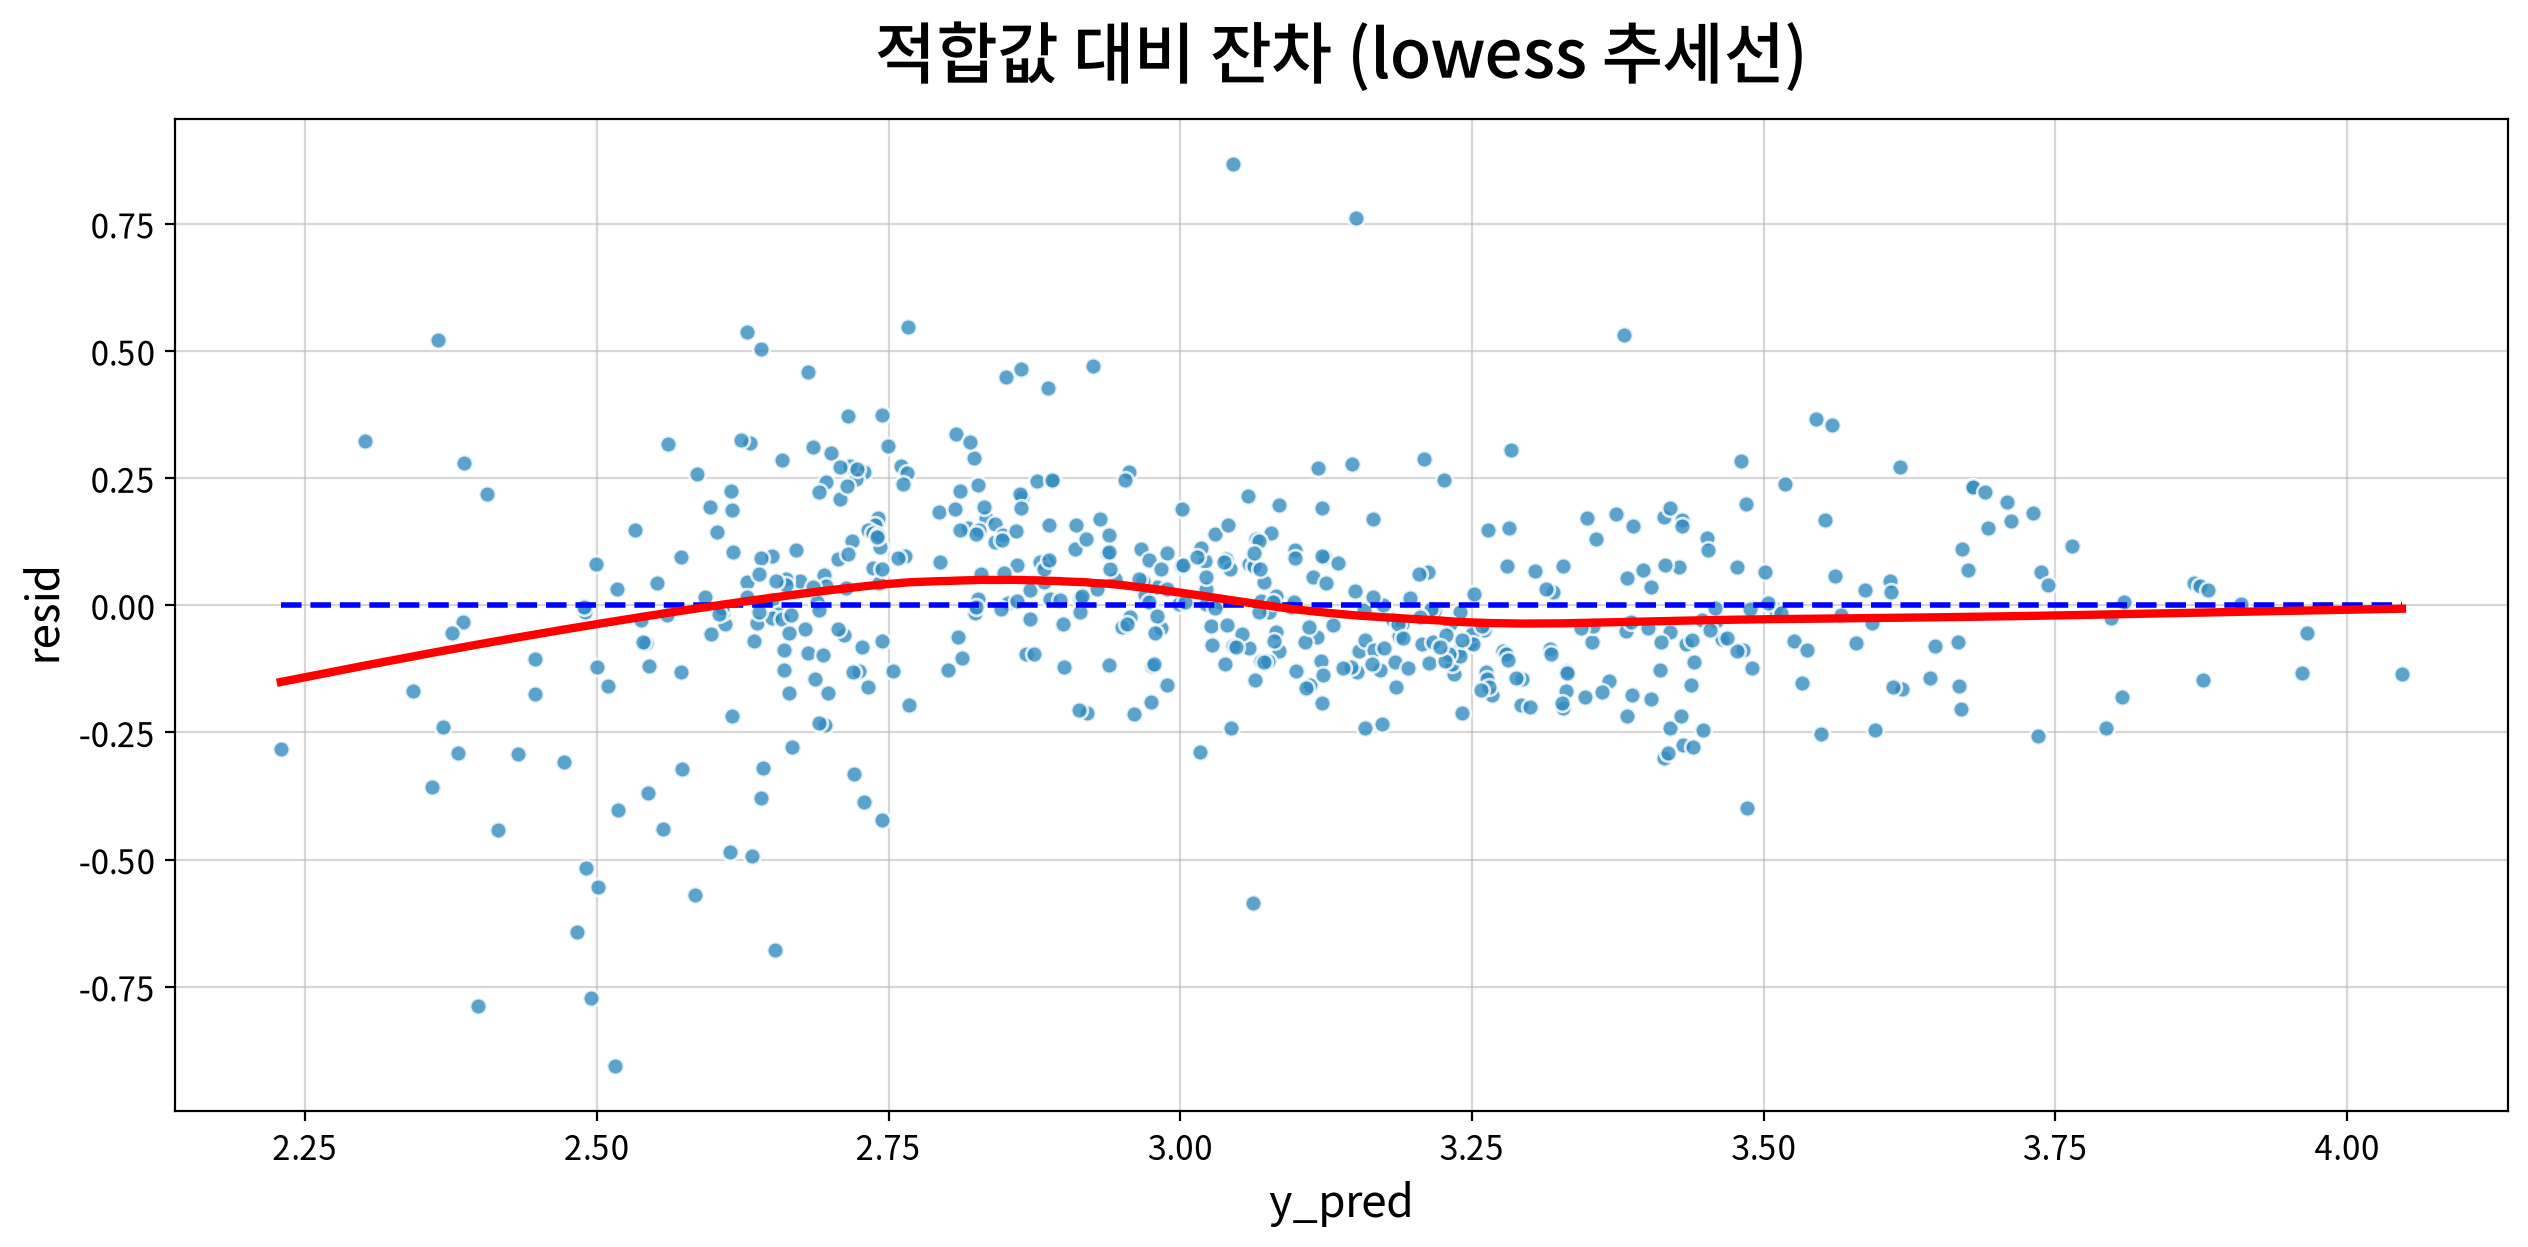

In [18]:
my_ols.test_linear(final_fit, plot=True,
                   title="적합값 대비 잔차 (lowess 추세선)")

### 2. 정규성 검정

,statistic,p-value,normality,result
Kolmogorov-Smirnov,0.066,0.024,False,대립가설 채택 → 정규성 위배


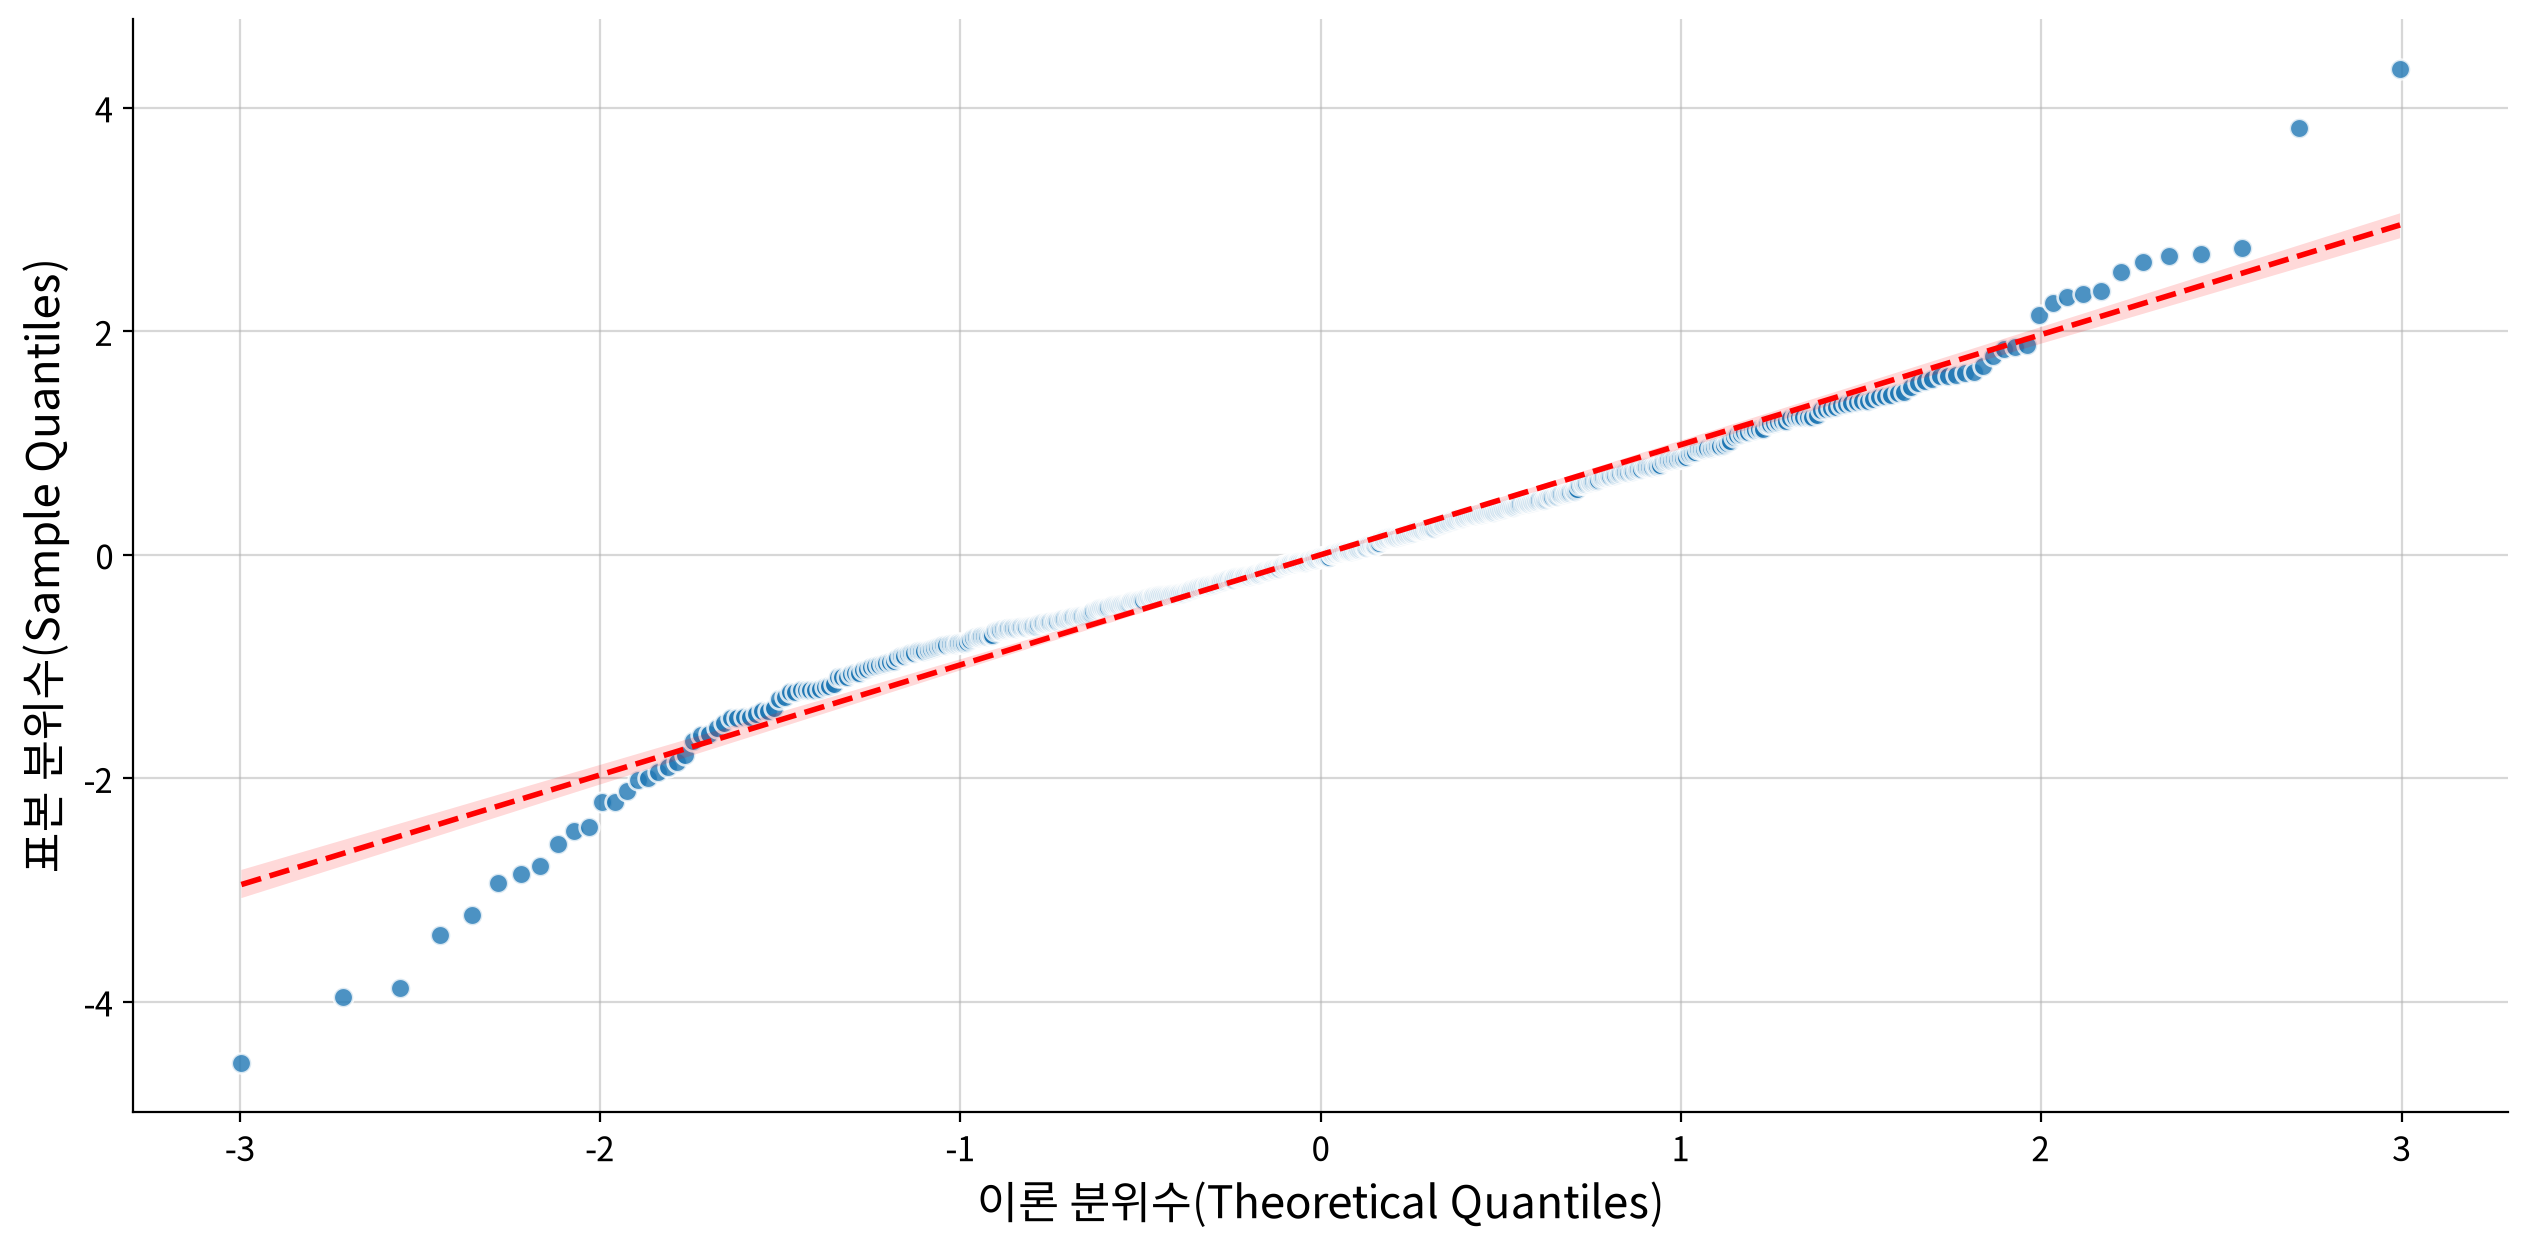

,기대(%),허용범위(%),실제(%),판정
구간,,,,
±1√MSE,68.000,64~72,76.680,위배
±2√MSE,95.000,93~97,94.860,충족
±3√MSE,99.700,99~100,98.620,위배


√MSE = 0.20 · 구간 규칙 판정: 정규성 위배


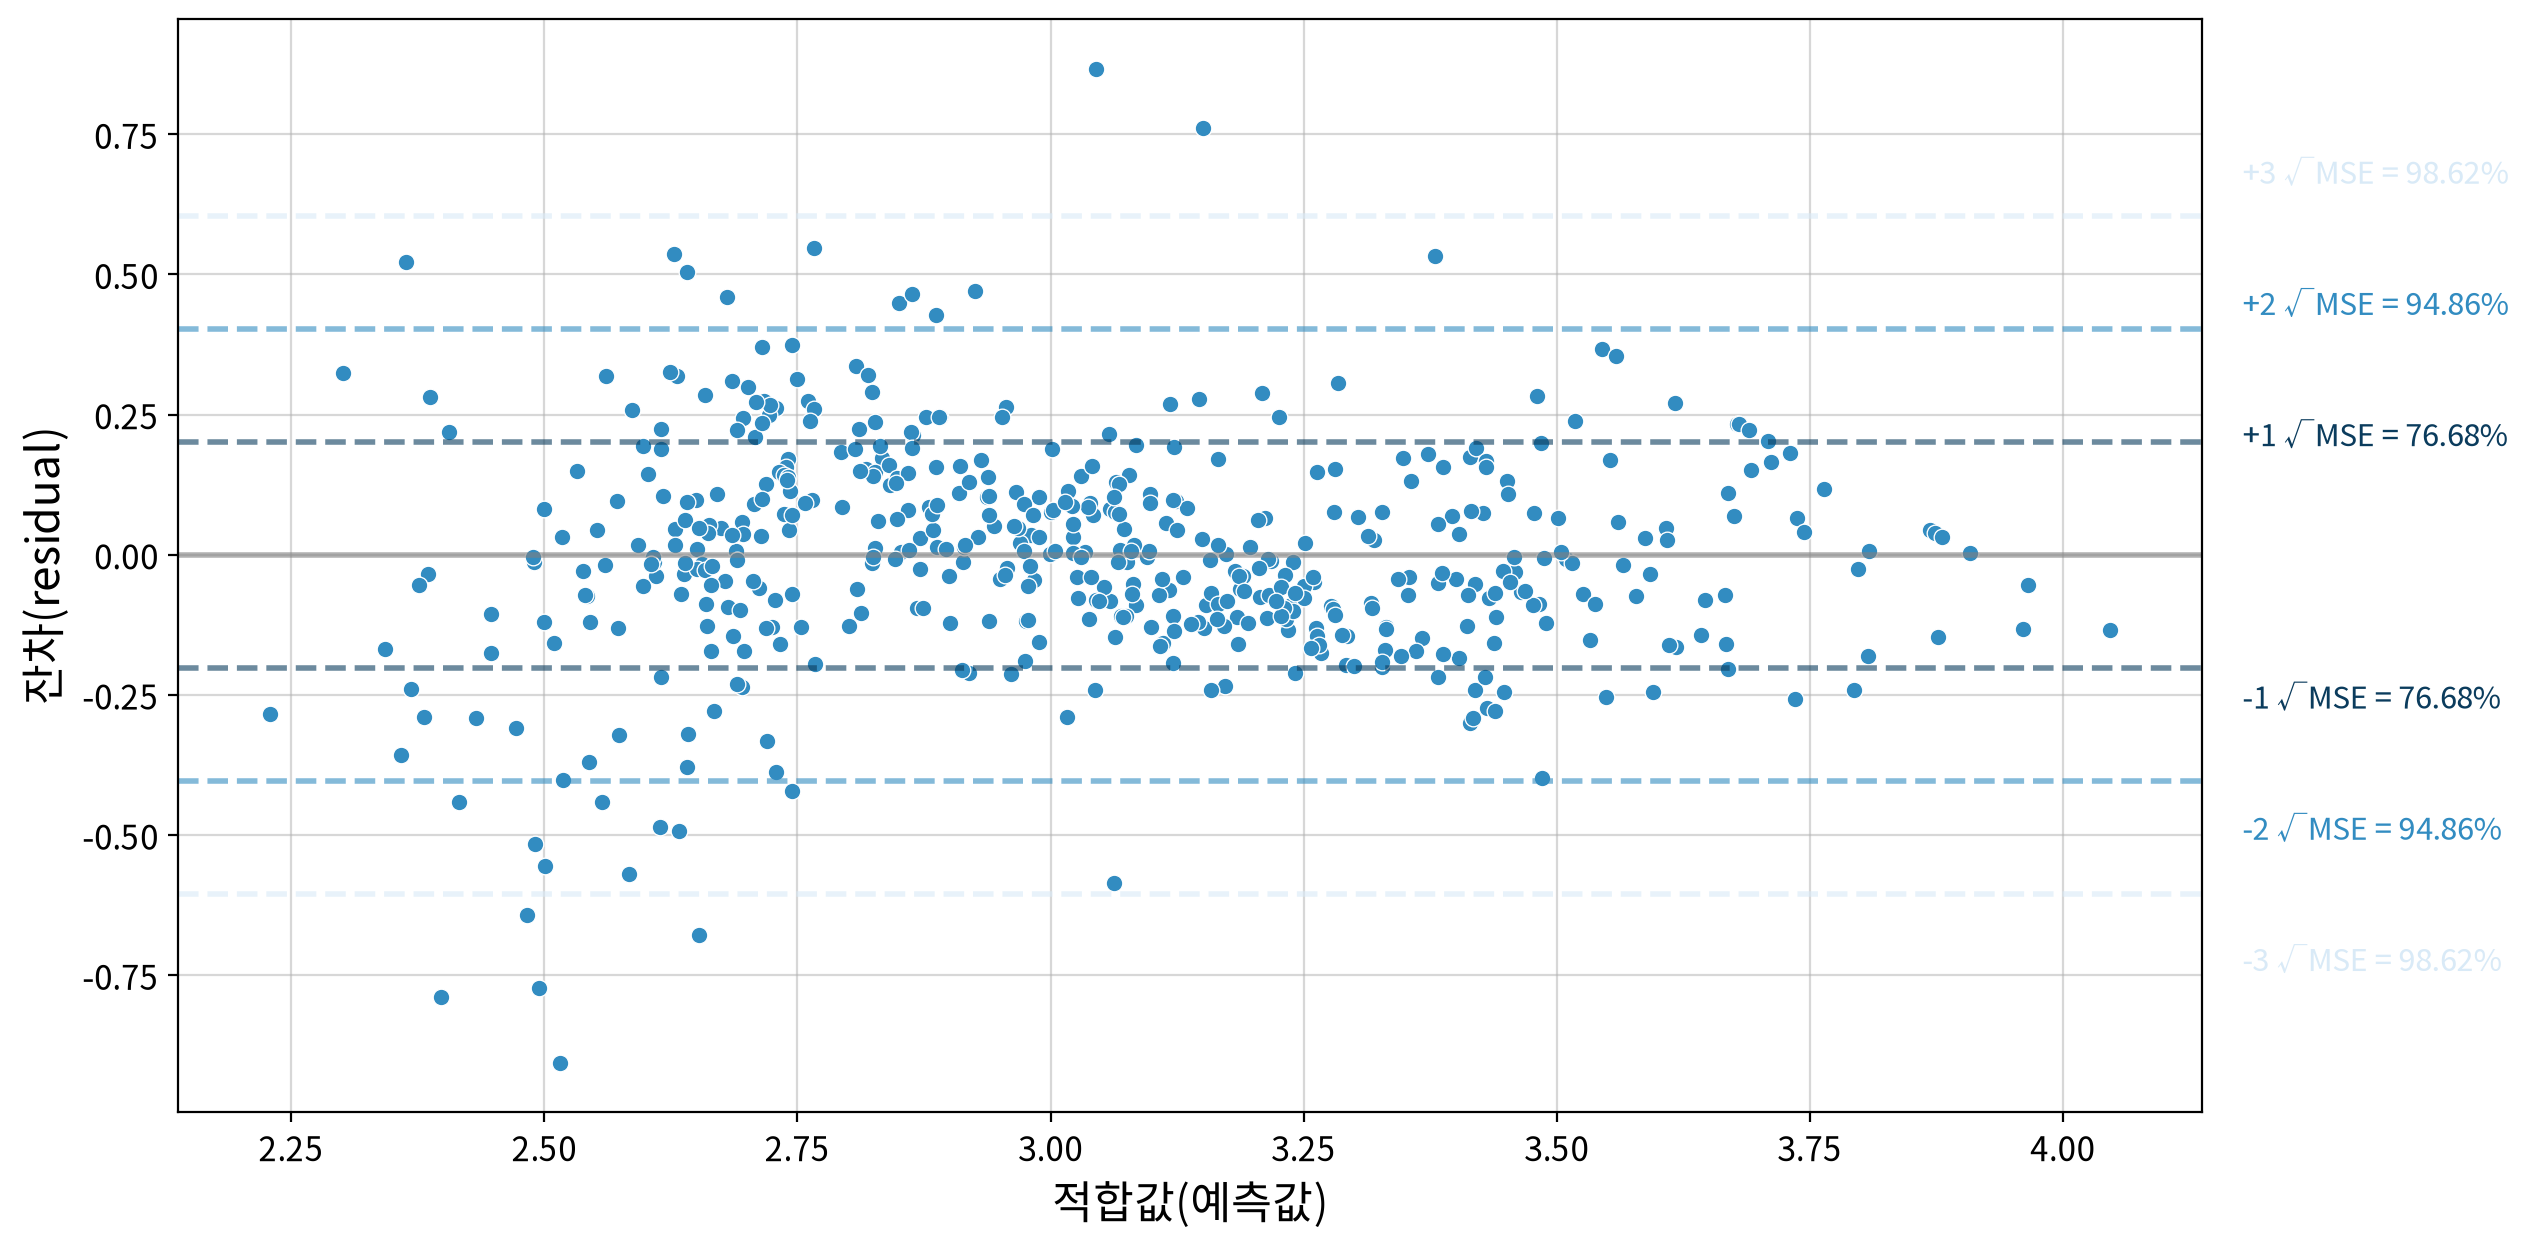

In [19]:
my_ols.test_normal(final_fit, plot=True)

### 3. 등분산성 검정

In [20]:
my_ols.test_equalvar(final_fit)

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Bruesch-Pagan,91.866,0.000,10.980,0.000,False,대립가설 채택 → 등분산 아님


### 4. 독립성 검정

In [21]:
my_ols.test_independent(final_fit)

,statistic,independence,result
Durbin-Watsopn,0.945,False,독립성 위반 (양(+)의 자기상관)
